In [ ]:
from google.colab import drive as dr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
parent_dr = 'data/'
act_raw= pd.read_csv(parent_dr+'2A1_monthly_activity_paper.csv',encoding ='cp949')
act_raw.head()

act = act_raw.melt(id_vars=['year', 'month'], var_name='SOURCE', value_name='ton')
coastal_set = {'HR-OK', 'SP-SC', 'SS-DH'}
act['Region'] = act['SOURCE'].apply(lambda x: 'Coastal area' if x in coastal_set else 'Inland area')

#check1 #share
nir_2022= 43011 #ton
df_2022 = act[act['year'] == 2022]
val_2022_kt = df_2022['ton'].sum() / 1000
print(f"The study coverage: {val_2022_kt:,.2f} kt")
coverage_ratio = (val_2022_kt/nir_2022) *100
print(f"2022 Annual National Total (from activity data): {val_2022_kt:,.2f} kt")
print(f"Coverage compared to NIR 2022: {coverage_ratio:.1f}%")

#check2 #composition
region_sums = df_2022.groupby('Region')['ton'].sum() / 1000
coastal_ratio_of_nir = (region_sums['Coastal area'] / nir_2022) * 100
inland_ratio_of_nir = (region_sums['Inland area'] / nir_2022) * 100
total_coverage_of_nir = coastal_ratio_of_nir + inland_ratio_of_nir
print(f"--- 2022 NIR ({nir_2022} kt) ---")
print(f"Coastal Area: {coastal_ratio_of_nir:.1f}%")
print(f"Inland Area:  {inland_ratio_of_nir:.1f}%")
print(f"Total Analyzed Coverage: {total_coverage_of_nir:.1f}%")

The study coverage: 42,287.08 kt
2022 Annual National Total (from activity data): 42,287.08 kt
Coverage compared to NIR 2022: 98.3%
--- 2022 NIR (43011 kt) ---
Coastal Area: 49.7%
Inland Area:  48.6%
Total Analyzed Coverage: 98.3%


# Statisc  check


In [ ]:
# Coastal area 회사들 필터링
coastal_companies = act[act['Region'] == 'Coastal area']

# 연도별 생산량 합계
prod_2018 = coastal_companies[coastal_companies['year'] == 2018]['ton'].sum()
prod_2019 = coastal_companies[coastal_companies['year'] == 2019]['ton'].sum()

# 2018 대비 2019 변화율
change_pct = ((prod_2019 - prod_2018) / prod_2018) * 100

print(f"=== Coastal Area 생산량 ===")
print(f"2018년 생산량: {prod_2018:,.2f} ton ({prod_2018/1000:,.2f} kt)")
print(f"2019년 생산량: {prod_2019:,.2f} ton ({prod_2019/1000:,.2f} kt)")
print(f"2018 대비 2019 변화율: {change_pct:+.1f}%")

=== Coastal Area 생산량 ===
2018년 생산량: 23,141,135.00 ton (23,141.13 kt)
2019년 생산량: 24,080,765.00 ton (24,080.76 kt)
2018 대비 2019 변화율: +4.1%


In [ ]:
act.head()

,year,month,SOURCE,ton,Region
0,2016,1,SP-SC,624706.0,Coastal area
1,2016,2,SP-SC,455694.0,Coastal area
2,2016,3,SP-SC,607757.0,Coastal area
3,2016,4,SP-SC,631372.0,Coastal area
4,2016,5,SP-SC,670283.0,Coastal area


In [ ]:
# SOURCE가 SS-YW인 곳 필터링
ss_yw = act[act['SOURCE'] == 'SS-YW']
# 2018 기준값
base_2018 = ss_yw[ss_yw['year'] == 2018]['ton'].sum()

print(f"=== SS-YW | 2018 대비 연도별 생산량 증감 ===")
print(f"{'연도':<6} {'생산량(ton)':>15} {'증감(ton)':>15} {'증감률':>10}")
print("-" * 50)

for year in sorted(ss_yw['year'].unique()):
    val = ss_yw[ss_yw['year'] == year]['ton'].sum()
    diff = val - base_2018
    pct = ((val - base_2018) / base_2018) * 100 if base_2018 > 0 else float('nan')
    marker = " ← base" if year == 2018 else ""
    print(f"{year:<6} {val:>15,.2f} {diff:>+15,.2f} {pct:>+9.1f}%{marker}")

=== SS-YW | 2018 대비 연도별 생산량 증감 ===
연도            생산량(ton)         증감(ton)        증감률
--------------------------------------------------
2016      2,881,331.00     +274,097.00     +10.5%
2017      2,738,593.00     +131,359.00      +5.0%
2018      2,607,234.00           +0.00      +0.0% ← base
2019      2,553,952.00      -53,282.00      -2.0%
2020      2,324,253.00     -282,981.00     -10.9%
2021      2,432,942.00     -174,292.00      -6.7%
2022      2,404,711.00     -202,523.00      -7.8%
2023      2,398,038.00     -209,196.00      -8.0%


In [ ]:
# SS-YW 제외한 나머지 SOURCE들
others = act[act['SOURCE'] != 'SS-YW']

print(f"=== SS-YW 제외 | 2018 대비 연도별 평균 증감률 ===")
print(f"{'연도':<6} {'평균 증감률':>12}")
print("-" * 25)

for year in sorted(others['year'].unique()):
    pct_list = []
    for source in others['SOURCE'].unique():
        src_data = others[others['SOURCE'] == source]
        base = src_data[src_data['year'] == 2018]['ton'].sum()
        val = src_data[src_data['year'] == year]['ton'].sum()
        if base > 0:
            pct = ((val - base) / base) * 100
            pct_list.append(pct)

    avg_pct = sum(pct_list) / len(pct_list) if pct_list else float('nan')
    marker = " ← base" if year == 2018 else ""
    print(f"{year:<6} {avg_pct:>+11.1f}%{marker}")

=== SS-YW 제외 | 2018 대비 연도별 평균 증감률 ===
연도           평균 증감률
-------------------------
2016         +15.6%
2017          +8.4%
2018          +0.0% ← base
2019          +7.4%
2020          -7.5%
2021          +4.0%
2022          +2.7%
2023          -1.3%


In [ ]:
print(f"=== 전체 대비 SS-YW 비중 ===")
print(f"{'연도':<6} {'SS-YW(ton)':>15} {'전체(ton)':>15} {'비중':>10}")
print("-" * 50)

for year in sorted(act['year'].unique()):
    ss_val = act[(act['SOURCE'] == 'SS-YW') & (act['year'] == year)]['ton'].sum()
    total_val = act[act['year'] == year]['ton'].sum()
    ratio = (ss_val / total_val) * 100 if total_val > 0 else float('nan')
    print(f"{year:<6} {ss_val:>15,.2f} {total_val:>15,.2f} {ratio:>+9.1f}%")

=== 전체 대비 SS-YW 비중 ===
연도          SS-YW(ton)         전체(ton)         비중
--------------------------------------------------
2016      2,881,331.00   48,442,984.00      +5.9%
2017      2,738,593.00   47,928,961.00      +5.7%
2018      2,607,234.00   44,645,118.00      +5.8%
2019      2,553,952.00   45,206,281.00      +5.6%
2020      2,324,253.00   41,226,021.00      +5.6%
2021      2,432,942.00   42,795,417.00      +5.7%
2022      2,404,711.00   42,287,083.00      +5.7%
2023      2,398,038.00   41,654,134.00      +5.8%


In [ ]:
print("=== 연도별 공장별 비중 (%) ===")

sources = sorted(act['SOURCE'].unique())
years = sorted(act['year'].unique())

# 헤더
header = f"{'연도':<6}" + "".join(f"{s:>10}" for s in sources) + f"{'SS-DH+YW':>12}" + f"{'합계':>10}"
print(header)
print("-" * (6 + 10 * len(sources) + 22))

for year in years:
    total_val = act[act['year'] == year]['ton'].sum()
    row = f"{year:<6}"
    for source in sources:
        val = act[(act['SOURCE'] == source) & (act['year'] == year)]['ton'].sum()
        ratio = (val / total_val) * 100 if total_val > 0 else float('nan')
        row += f"{ratio:>9.1f}%"

    # SS-DH + SS-YW 합산 비중
    dh_val = act[(act['SOURCE'] == 'SS-DH') & (act['year'] == year)]['ton'].sum()
    yw_val = act[(act['SOURCE'] == 'SS-YW') & (act['year'] == year)]['ton'].sum()
    combined_ratio = ((dh_val + yw_val) / total_val) * 100 if total_val > 0 else float('nan')
    row += f"{combined_ratio:>11.1f}%"
    row += f"{'100.0%':>10}"
    print(row)

=== 연도별 공장별 비중 (%) ===
연도         AS-JC     HH-SG     HH-YW     HL-DY     HR-OK     SP-SC     SS-DH     SS-DY     SS-YW    SS-DH+YW        합계
----------------------------------------------------------------------------------------------------------------------
2016        7.1%      2.4%      7.5%     13.0%     12.0%     16.5%     21.7%     13.8%      5.9%       27.7%    100.0%
2017        7.7%      1.5%      7.4%     13.1%     13.0%     17.5%     21.0%     13.1%      5.7%       26.7%    100.0%
2018        7.0%      1.5%      7.8%     12.5%     12.6%     15.9%     23.3%     13.5%      5.8%       29.2%    100.0%
2019        6.8%      2.4%      7.8%     10.7%     13.0%     17.8%     22.5%     13.5%      5.6%       28.2%    100.0%
2020        7.5%      1.4%      8.1%     11.2%     13.6%     16.6%     22.5%     13.4%      5.6%       28.2%    100.0%
2021        7.4%      2.6%      8.1%     11.2%     12.8%     16.2%     22.5%     13.6%      5.7%       28.2%    100.0%
2022        7.3%      2.6

In [ ]:
print("=== SS-DH+YW 비중 변화와 전체 배출량 영향 ===")
print(f"{'연도':<6} {'전체(kt)':>10} {'SS-DH+YW(kt)':>14} {'비중':>8} {'전년比 전체':>12} {'전년比 SS-DH+YW':>16}")
print("-" * 70)

prev_total = None
prev_combined = None

for year in sorted(act['year'].unique()):
    total_val = act[act['year'] == year]['ton'].sum() / 1000
    dh_val = act[(act['SOURCE'] == 'SS-DH') & (act['year'] == year)]['ton'].sum() / 1000
    yw_val = act[(act['SOURCE'] == 'SS-YW') & (act['year'] == year)]['ton'].sum() / 1000
    combined = dh_val + yw_val
    ratio = (combined / total_val) * 100

    chg_total    = f"{((total_val - prev_total) / prev_total * 100):+.1f}%" if prev_total else "-"
    chg_combined = f"{((combined - prev_combined) / prev_combined * 100):+.1f}%" if prev_combined else "-"

    print(f"{year:<6} {total_val:>10,.1f} {combined:>14,.1f} {ratio:>7.1f}% {chg_total:>12} {chg_combined:>16}")

    prev_total = total_val
    prev_combined = combined

=== SS-DH+YW 비중 변화와 전체 배출량 영향 ===
연도         전체(kt)   SS-DH+YW(kt)       비중       전년比 전체     전년比 SS-DH+YW
----------------------------------------------------------------------
2016     48,443.0       13,402.8    27.7%            -                -
2017     47,929.0       12,801.0    26.7%        -1.1%            -4.5%
2018     44,645.1       13,030.6    29.2%        -6.9%            +1.8%
2019     45,206.3       12,745.4    28.2%        +1.3%            -2.2%
2020     41,226.0       11,618.1    28.2%        -8.8%            -8.8%
2021     42,795.4       12,063.7    28.2%        +3.8%            +3.8%
2022     42,287.1       11,786.5    27.9%        -1.2%            -2.3%
2023     41,654.1       12,155.2    29.2%        -1.5%            +3.1%


In [ ]:
print("=== SS-DH+YW 변화가 전체에 기여한 실제 영향 ===")
print(f"{'연도':<6} {'전체변화(kt)':>13} {'SS-DH+YW 기여(kt)':>18} {'기여비율':>10}")
print("-" * 50)

years = sorted(act['year'].unique())
for i in range(1, len(years)):
    prev, curr = years[i-1], years[i]

    total_chg = (act[act['year']==curr]['ton'].sum() - act[act['year']==prev]['ton'].sum()) / 1000

    dh_chg = (act[(act['SOURCE']=='SS-DH')&(act['year']==curr)]['ton'].sum() -
              act[(act['SOURCE']=='SS-DH')&(act['year']==prev)]['ton'].sum()) / 1000
    yw_chg = (act[(act['SOURCE']=='SS-YW')&(act['year']==curr)]['ton'].sum() -
              act[(act['SOURCE']=='SS-YW')&(act['year']==prev)]['ton'].sum()) / 1000
    combined_chg = dh_chg + yw_chg

    contrib = (combined_chg / total_chg * 100) if total_chg != 0 else float('nan')
    print(f"{prev}→{curr} {total_chg:>+12.1f} {combined_chg:>+17.1f} {contrib:>9.1f}%")

=== SS-DH+YW 변화가 전체에 기여한 실제 영향 ===
연도          전체변화(kt)    SS-DH+YW 기여(kt)       기여비율
--------------------------------------------------
2016→2017       -514.0            -601.8     117.1%
2017→2018      -3283.8            +229.6      -7.0%
2018→2019       +561.2            -285.2     -50.8%
2019→2020      -3980.3           -1127.3      28.3%
2020→2021      +1569.4            +445.5      28.4%
2021→2022       -508.3            -277.1      54.5%
2022→2023       -632.9            +368.7     -58.3%


In [ ]:
# 코로나 이후 회복률 비교 (2020 → 2022)
print("=== 2020 → 2022 회복 비교 ===")

# SS-YW
ss = act[act['SOURCE'] == 'SS-YW']
ss_2020 = ss[ss['year'] == 2020]['ton'].sum()
ss_2022 = ss[ss['year'] == 2022]['ton'].sum()
print(f"SS-YW 회복률: {((ss_2022-ss_2020)/ss_2020)*100:+.1f}%")

# 나머지 공장 평균
for source in act[act['SOURCE'] != 'SS-YW']['SOURCE'].unique():
    src = act[act['SOURCE'] == source]
    v2020 = src[src['year'] == 2020]['ton'].sum()
    v2022 = src[src['year'] == 2022]['ton'].sum()
    if v2020 > 0:
        print(f"{source} 회복률: {((v2022-v2020)/v2020)*100:+.1f}%")

=== 2020 → 2022 회복 비교 ===
SS-YW 회복률: +3.5%
SP-SC 회복률: -1.0%
SS-DH 회복률: +0.9%
HL-DY 회복률: +8.0%
HH-SG 회복률: +86.5%
HH-YW 회복률: +0.4%
AS-JC 회복률: +0.3%
SS-DY 회복률: +8.3%
HR-OK 회복률: -7.0%


In [ ]:
# 2016년을 base로 재계산해서 장기 추세 확인
base_2016 = act[(act['SOURCE'] == 'SS-YW') & (act['year'] == 2018)]['ton'].sum()

print("=== SS-YW | 2016 기준 장기 추세 ===")
for year in sorted(act[act['SOURCE'] == 'SS-YW']['year'].unique()):
    val = act[(act['SOURCE'] == 'SS-YW') & (act['year'] == year)]['ton'].sum()
    pct = ((val - base_2016) / base_2016) * 100
    print(f"{year}: {pct:+.1f}%")

=== SS-YW | 2016 기준 장기 추세 ===
2016: +10.5%
2017: +5.0%
2018: +0.0%
2019: -2.0%
2020: -10.9%
2021: -6.7%
2022: -7.8%
2023: -8.0%


In [ ]:
#GCAM6.0 NetZero2050 달성한다는 시나리오에서 탄소가격
#2025년부터 감축

# [1] historical emission 2016 ~ 2023

In [ ]:
ef = 0.5295; ckkd = 1.02
ef_2030= 0.5138 #2% linear transition #2025년부터 감축하는 형태
ef_2050= 0.4352 #12% liner transition

act['emission'] = act['ton'] * ef * ckkd #tonCO2
act['kt'] = act['emission']/1e3
act['mt'] = act['emission']/1e6
act.head()
code_mapping = {'SP-SC': 'C2', 'SS-DH': 'C1', 'HR-OK': 'C3','SS-DY': 'L1', 'HL-DY': 'L2', 'HH-SG': 'L3','AS-JC':'L4','SS-YW':'L5','HH-YW':'L6'}
act['code'] = act['SOURCE'].map(code_mapping)
act['date'] = pd.to_datetime(act[['year', 'month']].assign(day=1))
act.tail()
act.columns

Index(['year', 'month', 'SOURCE', 'ton', 'Region', 'emission', 'kt', 'mt',
       'code', 'date'],
      dtype='object')

In [ ]:
# Coastal area 회사들 필터링
coastal_companies = act[act['Region'] == 'Coastal area']

# 연도별 생산량 합계
prod_2018 = coastal_companies[coastal_companies['year'] == 2018]['kt'].sum()
prod_2019 = coastal_companies[coastal_companies['year'] == 2019]['kt'].sum()

# 2018 대비 2019 변화율
change_pct = ((prod_2019 - prod_2018) / prod_2018) * 100

print(f"=== Coastal Area 배출량 ===")
print(f"2018년 배출량: {prod_2018:,.2f} ton ({prod_2018/1000:,.2f} kt)")
print(f"2019년 배출량: {prod_2019:,.2f} ton ({prod_2019/1000:,.2f} kt)")
print(f"2018 대비 2019 변화율: {change_pct:+.1f}%")

=== Coastal Area 배출량 ===
2018년 배출량: 12,498.30 ton (12.50 kt)
2019년 배출량: 13,005.78 ton (13.01 kt)
2018 대비 2019 변화율: +4.1%


CSV 저장 완료 ✅


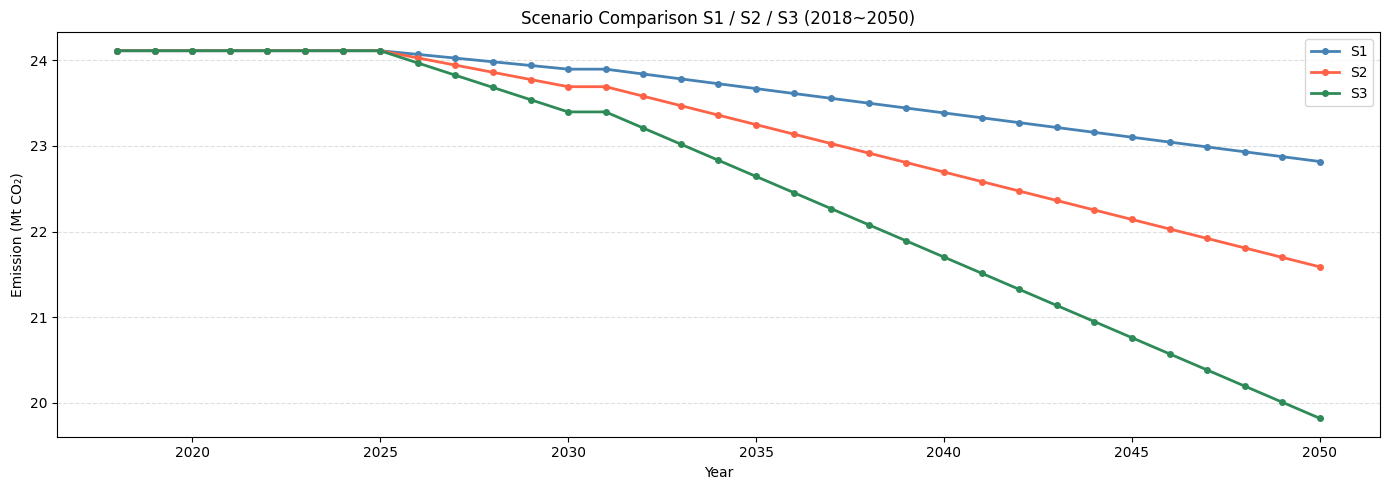

In [ ]:
# ══════════════════════════════════════════
# 1) 기준 데이터 준비
# ══════════════════════════════════════════
base_ton = (act[act['year'] == 2018].groupby(['Region', 'month'])['ton'].sum())

years          = range(2018, 2051)
regions        = act['Region'].dropna().unique()
months         = range(1, 13)
coastal_months = {1, 3, 4, 5, 9, 10, 11}

# ══════════════════════════════════════════
# 2) 배출계수 함수
# ══════════════════════════════════════════
def get_ef_s1(year):
    if year < 2025:
        return ef
    elif 2025 <= year <= 2030:
        t = (year - 2025) / (2030 - 2025)
        return ef + t * (ef_2030 - ef)
    elif 2031 <= year <= 2050:
        t = (year - 2031) / (2050 - 2031)
        return ef_2030 + t * (ef_2050 - ef_2030)
    else:
        return ef_2050

# ══════════════════════════════════════════
# 3) 시나리오 생성 함수
# ══════════════════════════════════════════
def build_scenario(target_regions, target_months=None, scenario_name='S'):
    """
    target_regions : set, 변동 ef 적용할 region
    target_months  : set or None (None이면 모든 월 적용)
    """
    rows = []
    for year in years:
        ef_s1 = get_ef_s1(year)
        for month in months:
            for region in regions:
                ton = base_ton.get((region, month), np.nan)

                month_cond = (target_months is None) or (month in target_months)

                if region in target_regions and month_cond and year >= 2025:
                    ef_used = ef_s1
                else:
                    ef_used = ef

                emission = ton * ef_used * ckkd

                rows.append({
                    'year'    : year,
                    'month'   : month,
                    'region'  : region,
                    'ton'     : ton,
                    'ef_used' : round(ef_used, 6),
                    'emission': emission,
                    'kt'      : emission / 1e3,
                    'mt'      : emission / 1e6,
                    'date'    : pd.Timestamp(year=year, month=month, day=1),
                    'scenario': scenario_name,})

    df = pd.DataFrame(rows)
    annual = df.groupby('year')[['emission','kt','mt']].sum().reset_index()
    annual['scenario'] = scenario_name
    return df, annual

# ══════════════════════════════════════════
# 4) 세 가지 시나리오 실행
# ══════════════════════════════════════════
# S1: Coastal area + 특정 월
scen1, scen1_annual = build_scenario(
    target_regions={'Coastal area'},
    target_months=coastal_months,
    scenario_name='S1')

# S2: Coastal + Inland area + 특정 월
scen2, scen2_annual = build_scenario(target_regions={'Coastal area', 'Inland area'},
    target_months=coastal_months,scenario_name='S2')

# S3: Coastal + Inland area + 모든 월
scen3, scen3_annual = build_scenario(
    target_regions={'Coastal area', 'Inland area'},
    target_months=None,
    scenario_name='S3')

# ══════════════════════════════════════════
# 5) concat & CSV 저장
# ══════════════════════════════════════════
scen_all        = pd.concat([scen1, scen2, scen3], ignore_index=True)
scen_annual_all = pd.concat([scen1_annual, scen2_annual, scen3_annual], ignore_index=True)

scen_all.to_csv(parent_dr + 'scenarios_monthly.csv', index=False, encoding='utf-8-sig')
scen_annual_all.to_csv(parent_dr + 'scenarios_annual.csv', index=False, encoding='utf-8-sig')
print("CSV 저장 완료 ✅")

# ══════════════════════════════════════════
# 6) 시각화
# ══════════════════════════════════════════
colors = {'S1': 'steelblue', 'S2': 'tomato', 'S3': 'seagreen'}

fig, ax = plt.subplots(figsize=(14, 5))
for s, grp in scen_annual_all.groupby('scenario'):
    ax.plot(grp['year'], grp['mt'],
            color=colors[s], linewidth=2, marker='o', markersize=4, label=s)

ax.set_xlabel('Year')
ax.set_ylabel('Emission (Mt CO₂)')
ax.set_title('Scenario Comparison S1 / S2 / S3 (2018~2050)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# social value

In [ ]:
cpi_2010_to_2025 = 1.47
price_raw = pd.read_csv(parent_dr+'GCAM60_NetZero2050_PriceCarbon.csv', encoding='cp949')
price_raw.set_index('year', inplace=True)
price = price_raw.loc[2025:2050].copy()
price['carbon_price'] =  (price['US$2010_tCO2'] * cpi_2010_to_2025).interpolate(method='linear')

# 연간 → 월별 균등 배분 (flat)
price_monthly = price[['carbon_price']].copy()
price_monthly = price_monthly.loc[price_monthly.index.repeat(12)].copy()
price_monthly.index = pd.date_range(start='2025-01-01', end='2050-12-01', freq='MS')
price_monthly.index.name = 'date'

assert (price_monthly.resample('YS').mean().round(6).values == price[['carbon_price']].round(6).values).all(), \
    "연평균 불일치!"
print("검증 통과 ✅")
#print(price_monthly.head(15))
carbon_df = price_monthly.reset_index().copy()
carbon_df['year']  = carbon_df['date'].dt.year
carbon_df['month'] = carbon_df['date'].dt.month

검증 통과 ✅


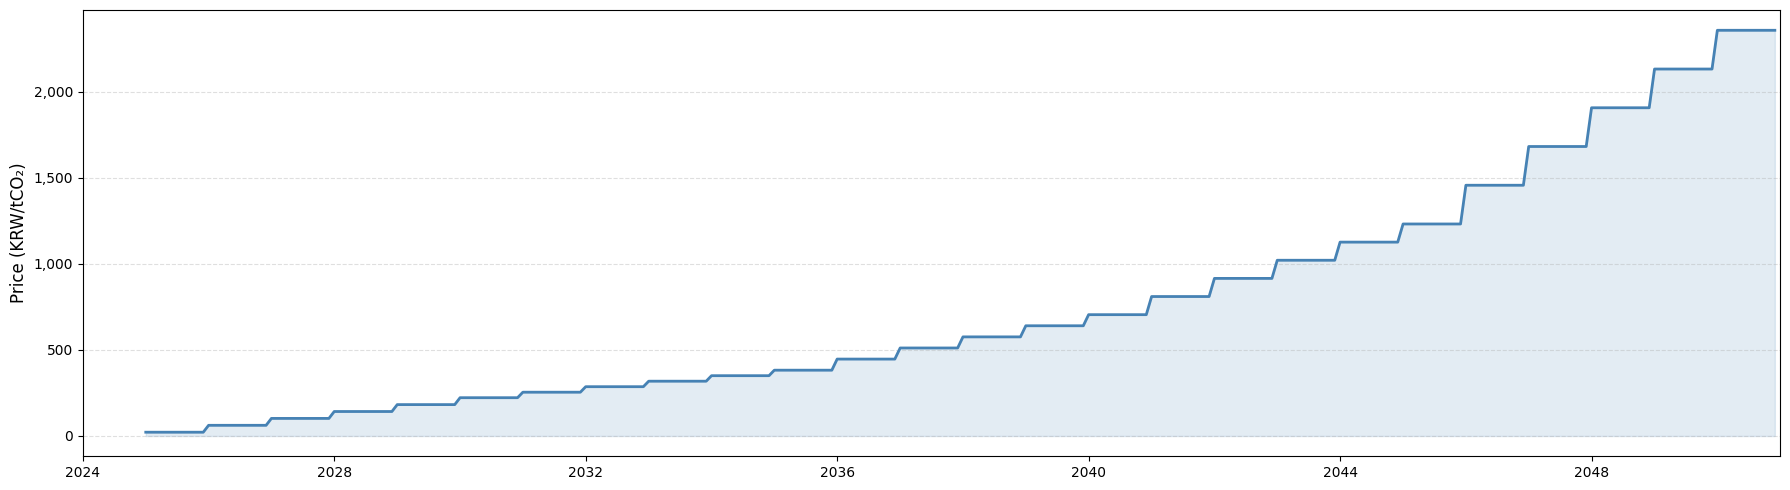

      carbon_price
year              
2025     21.964887
2026     62.040733
2027    102.116578
2028    142.192424
2029    182.268269
2030    222.344115
2031    254.303679
2032    286.263243
2033    318.222807
2034    350.182371
2035    382.141935
2036    446.611255
2037    511.080574
2038    575.549894
2039    640.019213
2040    704.488533
2041    809.806918
2042    915.125303
2043   1020.443689
2044   1125.762074
2045   1231.080459
2046   1456.017242
2047   1680.954026
2048   1905.890809
2049   2130.827593
2050   2355.764376


In [ ]:

# ── 4) 시각화
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(carbon_df['date'], carbon_df['carbon_price'],
        color='steelblue', linewidth=2, zorder=3)
ax.fill_between(carbon_df['date'], carbon_df['carbon_price'],
                color='steelblue', alpha=0.15)
ax.set_xlabel('')
ax.set_ylabel('Price (KRW/tCO₂)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2050-12-31'))

plt.tight_layout()
plt.show()

# 주요 연도 확인
#print(carbon_df[carbon_df['month']==12][['year','carbon_price']].set_index('year'))


In [ ]:
# ── 1) 2025~2050만 탄소가격 merge
scen_all_cost = scen_all[scen_all['year'] >= 2025].merge(carbon_df[['year','month','carbon_price']], on=['year','month'])


# 배출비용 (USD)
scen_all_cost['emission_cost_usd']  = scen_all_cost['emission'] * scen_all_cost['carbon_price']
scen_all_cost['emission_cost_musd'] = scen_all_cost['emission_cost_usd'] / 1e6


#  ── 2) 감축량 계산 (2018 기준)
base = (scen_all[(scen_all['scenario'] == 'S1') & (scen_all['year'] == 2018)].groupby(['region', 'month'])['emission'].sum().reset_index().rename(columns={'emission': 'base_emission'}))
reduction = scen_all_cost.merge(base, on=['region','month'])  # carbon_price 이미 있음
reduction['reduction_t']  = reduction['base_emission'] - reduction['emission']
reduction['reduction_kt'] = reduction['reduction_t'] / 1e3


# ── 3) soocial value: 감축량 × 탄소가격
reduction['social_usd']  = reduction['reduction_t'] * reduction['carbon_price']
reduction['social_musd'] = reduction['social_usd'] / 1e6


# ── 6) final merge & 저장
final = scen_all_cost.merge(reduction[['scenario','year','month','region','reduction_t','reduction_kt', 'social_usd','social_musd']],on=['scenario','year','month','region'])
print(final.shape)
print(final.columns.tolist())
final.to_csv(parent_dr + 'final_cost.csv', index=False, encoding='cp949')



(1872, 17)
['year', 'month', 'region', 'ton', 'ef_used', 'emission', 'kt', 'mt', 'date', 'scenario', 'carbon_price', 'emission_cost_usd', 'emission_cost_musd', 'reduction_t', 'reduction_kt', 'social_usd', 'social_musd']


In [ ]:
reduction_map = {'S1': 1294, 'S2': 2525, 'S3': 4294}

plant_annual = act.groupby(['year','code'])['kt'].sum().reset_index()
plant_annual = plant_annual.sort_values(['year','kt'], ascending=[True, False]).reset_index(drop=True)

# ── 각 시나리오 감축량과의 차이 컬럼 추가
for scen, red_kt in reduction_map.items():
    plant_annual[f'diff_{scen}'] = (plant_annual['kt'] - red_kt).abs().round(1)
    plant_annual[f'pct_{scen}']  = (plant_annual['kt'] / red_kt * 100).round(1)

print(plant_annual.to_string(index=False))

# ── 각 시나리오별 가장 가까운 값
print(f"\n{'='*60}")
for scen, red_kt in reduction_map.items():
    closest = plant_annual.loc[plant_annual[f'diff_{scen}'].idxmin()]
    print(f"  [{scen}] {red_kt:,} kt와 가장 유사:")
    print(f"  → {closest['year']}년 {closest['code']}공장 "
          f"({closest['kt']:,.0f} kt, 차이 {closest[f'diff_{scen}']:.0f} kt)")

 year code          kt  diff_S1  pct_S1  diff_S2  pct_S2  diff_S3  pct_S3
 2016   C1 5682.531011   4388.5   439.1   3157.5   225.1   1388.5   132.3
 2016   C2 4328.432485   3034.4   334.5   1803.4   171.4     34.4   100.8
 2016   L1 3604.861490   2310.9   278.6   1079.9   142.8    689.1    84.0
 2016   L2 3389.448214   2095.4   261.9    864.4   134.2    904.6    78.9
 2016   C3 3147.784403   1853.8   243.3    622.8   124.7   1146.2    73.3
 2016   L6 1970.141922    676.1   152.3    554.9    78.0   2323.9    45.9
 2016   L4 1865.400648    571.4   144.2    659.6    73.9   2428.6    43.4
 2016   L5 1556.178060    262.2   120.3    968.8    61.6   2737.8    36.2
 2016   L3  618.792995    675.2    47.8   1906.2    24.5   3675.2    14.4
 2017   C1 5434.606477   4140.6   420.0   2909.6   215.2   1140.6   126.6
 2017   C2 4519.631366   3225.6   349.3   1994.6   179.0    225.6   105.3
 2017   L1 3400.799826   2106.8   262.8    875.8   134.7    893.2    79.2
 2017   L2 3389.128481   2095.1   261.